# 🚗 Bilvärderaren — pipeline

En enda notebook, cell för cell: **läs dataset → städa → modellera → utvärdera → output.**

- **Källa:** `dataset/car_price_dataset.csv` (10 000 bilar). Ingen scraping, ingen databas.
- **Mål (`price_sek`):** annonspriset. Datasetets `Price` saknar valuta — vi antar EUR och räknar
  om till SEK med en fast kurs (`EUR_SEK`, en kalibreringsratt du kan justera).
- **Vad vi skickar ut:** värdering (privat/handlare), fyndanalys, modelljämförelse och feature importance.

## 0. Beroenden & konstanter

Alla justerbara antaganden samlade på ett ställe.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

CSV = "dataset/car_price_dataset.csv"

# Datasetets Price saknar valuta -> anta EUR, räkna om till SEK. Justera vid behov.
EUR_SEK = 11.5
# Handlare tar påslag (garanti/marginal) -> privatköp är billigare. Datasetet saknar
# säljartyp, så gapet sätts deterministiskt här istället för att läras från data.
PRIVATE_MARGIN = 0.13
# Fynd-tröskel: >=10 % under marknadsvärde = fynd, >=10 % över = dyr.
DEAL_THRESHOLD = 0.10

## 1. Läs in datasetet

In [17]:
raw = pd.read_csv(CSV, sep=";")
print(f"{len(raw)} rader, {raw.shape[1]} kolumner")
raw.head()

10000 rader, 10 kolumner


,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


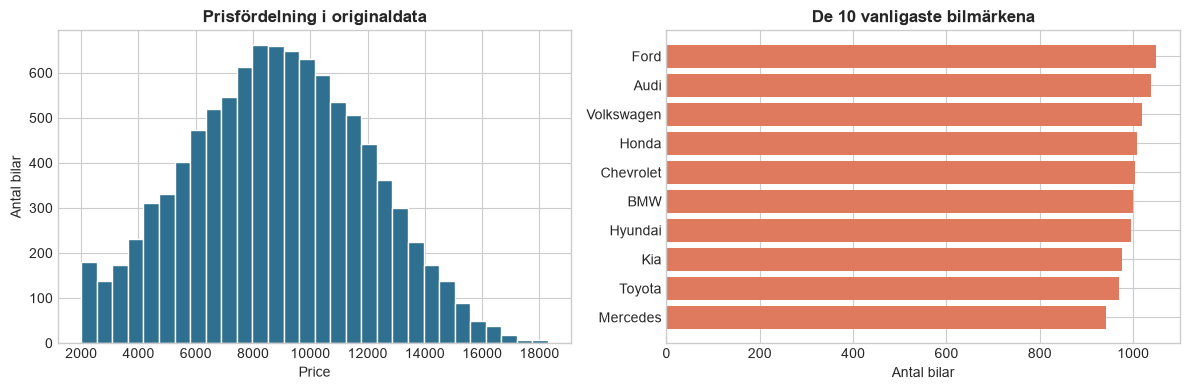

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(raw["Price"], bins=30, color="#2f6f8f", edgecolor="white")
axes[0].set_title("Prisfördelning i originaldata")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Antal bilar")

brand_counts = raw["Brand"].value_counts().head(10).sort_values()
axes[1].barh(brand_counts.index, brand_counts.values, color="#e07a5f")
axes[1].set_title("De 10 vanligaste bilmärkena")
axes[1].set_xlabel("Antal bilar")

plt.tight_layout()
plt.show()

## 2. Städa & utforska

Kolla dubletter och saknade värden, ta bort dubletter och räkna om priset till SEK.

In [19]:
print("Dubletter:", raw.duplicated().sum())
print("Saknade värden per kolumn:")
print(raw.isna().sum())

df = raw.drop_duplicates().reset_index(drop=True)
df["price_sek"] = (df["Price"] * EUR_SEK).round().astype(int)
df.describe(include="all").T

Dubletter: 0
Saknade värden per kolumn:
Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Brand,10000,10,Ford,1048,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,10000,30,Accord,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,10000.0,NaN,NaN,NaN,2011.5437,6.897699,2000.0,2006.0,2012.0,2017.0,2023.0
Engine_Size,10000.0,NaN,NaN,NaN,3.00056,1.149324,1.0,2.0,3.0,4.0,5.0
Fuel_Type,10000,4,Electric,2625,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,10000,3,Manual,3372,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mileage,10000.0,NaN,NaN,NaN,149239.1118,86322.348957,25.0,74649.25,149587.0,223577.5,299947.0
Doors,10000.0,NaN,NaN,NaN,3.4971,1.110097,2.0,3.0,3.0,4.0,5.0
Owner_Count,10000.0,NaN,NaN,NaN,2.9911,1.422682,1.0,2.0,3.0,4.0,5.0
Price,10000.0,NaN,NaN,NaN,8852.9644,3112.59681,2000.0,6646.0,8858.5,11086.5,18301.0


## 2b. Varför visas `NaN` i beskrivningen?

`describe(include="all")` använder olika mått beroende på datatyp. För textkolumner som `Brand` och `Model` visas antal, antal unika värden och vanligaste värde. Statistik som medelvärde, standardavvikelse och kvartiler passar bara numeriska kolumner och blir därför `NaN` för textkolumner.

Det viktiga testet för riktiga saknade värden är `df.isna().sum()`. Där betyder ett värde större än noll att data faktiskt saknas.

Riktiga saknade värden:
Inga saknade värden


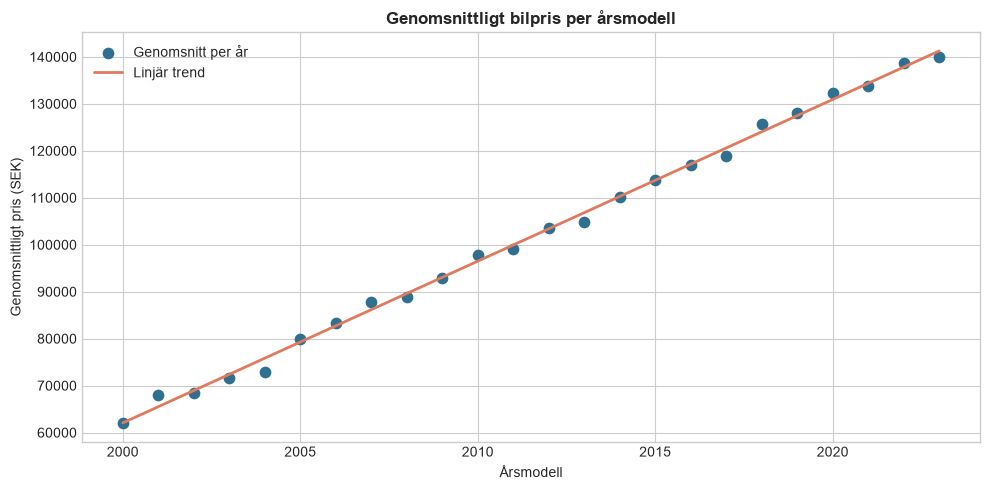

In [20]:
missing = df.isna().sum()
print("Riktiga saknade värden:")
print(missing[missing > 0] if missing.any() else "Inga saknade värden")

year_average = df.groupby("Year", as_index=False)["price_sek"].mean()
year_model = LinearRegression().fit(year_average[["Year"]], year_average["price_sek"])
year_average["trend_price"] = year_model.predict(year_average[["Year"]])

plt.figure(figsize=(10, 5))
plt.scatter(year_average["Year"], year_average["price_sek"], color="#2f6f8f", s=55, label="Genomsnitt per år")
plt.plot(year_average["Year"], year_average["trend_price"], color="#e07a5f", linewidth=2, label="Linjär trend")
plt.title("Genomsnittligt bilpris per årsmodell")
plt.xlabel("Årsmodell")
plt.ylabel("Genomsnittligt pris (SEK)")
plt.legend()
plt.tight_layout()
plt.show()

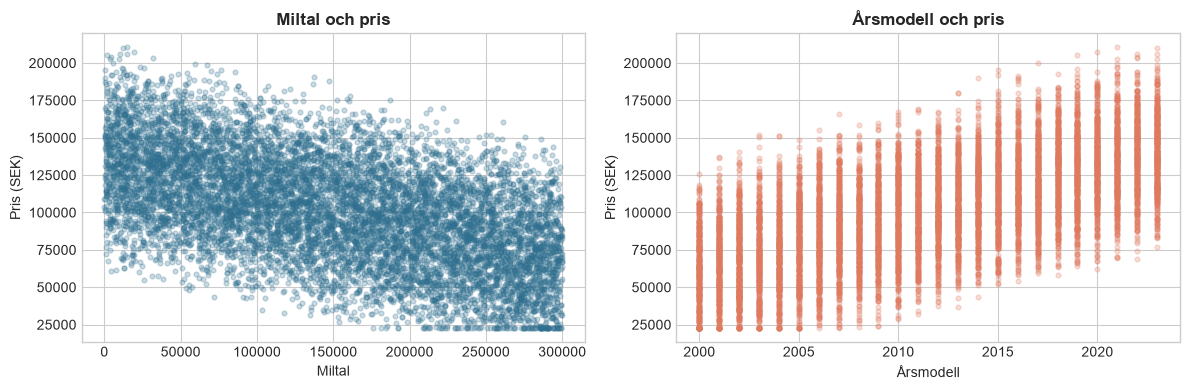

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df["Mileage"], df["price_sek"], alpha=0.25, s=12, color="#2f6f8f")
axes[0].set_title("Miltal och pris")
axes[0].set_xlabel("Miltal")
axes[0].set_ylabel("Pris (SEK)")

axes[1].scatter(df["Year"], df["price_sek"], alpha=0.25, s=12, color="#e07a5f")
axes[1].set_title("Årsmodell och pris")
axes[1].set_xlabel("Årsmodell")
axes[1].set_ylabel("Pris (SEK)")

plt.tight_layout()
plt.show()

## 3. Features & target

Kategoriska features one-hot-kodas, numeriska används som de är. `price_sek` är target.

In [22]:
CAT = ["Brand", "Model", "Fuel_Type", "Transmission"]
NUM = ["Year", "Engine_Size", "Mileage", "Doors", "Owner_Count"]
TARGET = "price_sek"

X, y = df[CAT + NUM], df[TARGET]

def make_pipe(model):
    """Preprocessing (one-hot på kategoriska, passthrough på numeriska) + modell."""
    prep = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT),
        ("num", "passthrough", NUM),
    ])
    return Pipeline([("prep", prep), ("model", model)])

## 4. Träna & utvärdera (80/20-split)

RandomForest på en train/test-split. MAE = snittfel i kr, R² = andel förklarad varians.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = make_pipe(RandomForestRegressor(n_estimators=200, random_state=42))
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
print(f"RandomForest — MAE={mean_absolute_error(y_test, pred):,.0f} kr, "
      f"R2={r2_score(y_test, pred):.3f}")

RandomForest — MAE=2,950 kr, R2=0.988


## 5. Modelljämförelse: RandomForest vs LinearRegression

Samma preprocessing och indata för båda. Per modell: MAE/MSE/RMSE på test-splitten plus
5-fold korsvalidering (MAE-medel ± std) på hela datan — mer tillförlitligt än en enda split.
Vinnaren (lägst CV-MAE) refit:as på **all** data och blir modellen vi predikterar med.

In [24]:
def new_model(name):
    return (RandomForestRegressor(n_estimators=200, random_state=42)
            if name == "RandomForest" else LinearRegression())

rows = {}
for name in ("RandomForest", "LinearRegression"):
    pipe = make_pipe(new_model(name))
    pipe.fit(X_train, y_train)
    p = pipe.predict(X_test)
    mse = mean_squared_error(y_test, p)
    cv = -cross_val_score(make_pipe(new_model(name)), X, y, cv=5,
                          scoring="neg_mean_absolute_error")
    rows[name] = {
        "MAE": mean_absolute_error(y_test, p), "MSE": mse, "RMSE": mse ** 0.5,
        "CV-MAE": cv.mean(), "CV-std": cv.std(),
    }

comparison = pd.DataFrame(rows).T
winner = comparison["CV-MAE"].idxmin()
print(f"Vinnare (lägst CV-MAE): {winner}")

# Refit vinnaren på ALL data -> modellen vi värderar med nedan.
model = make_pipe(new_model(winner)).fit(X, y)
comparison.round(0)

Vinnare (lägst CV-MAE): LinearRegression


,MAE,MSE,RMSE,CV-MAE,CV-std
RandomForest,2950.0,14396079.0,3794.0,2918.0,129.0
LinearRegression,1585.0,4040893.0,2010.0,1811.0,183.0


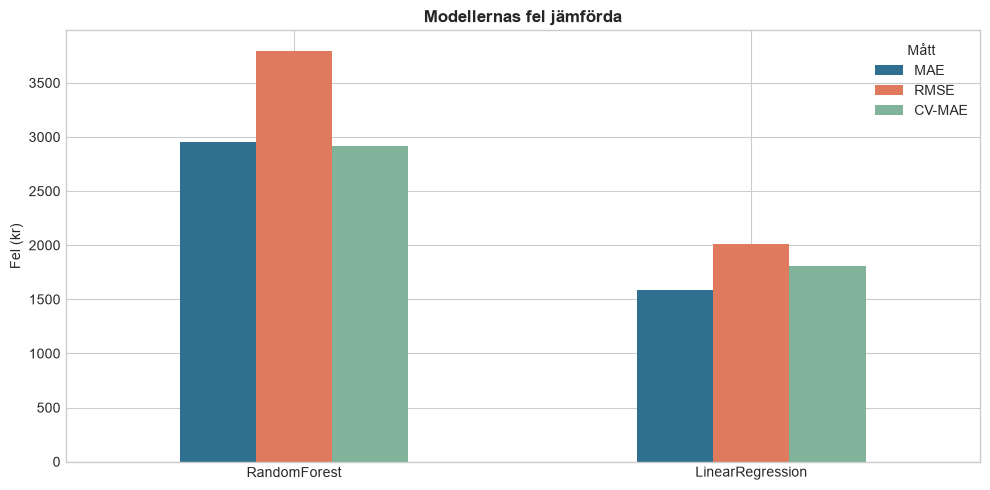

In [25]:
comparison[["MAE", "RMSE", "CV-MAE"]].plot(kind="bar", figsize=(10, 5), color=["#2f6f8f", "#e07a5f", "#81b29a"])
plt.title("Modellernas fel jämförda")
plt.ylabel("Fel (kr)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Mått")
plt.tight_layout()
plt.show()

## 6. Feature importance

Vilka features driver priset? Vi läser av en RandomForest (trädmodeller ger importance
direkt) och summerar one-hot-kolumnerna tillbaka till ursprungskolumnen.

In [26]:
imp_rf = make_pipe(RandomForestRegressor(n_estimators=200, random_state=42)).fit(X, y)
names = imp_rf.named_steps["prep"].get_feature_names_out()
importances = pd.Series(imp_rf.named_steps["model"].feature_importances_, index=names)

def to_original(feature_name):
    body = feature_name.split("__", 1)[1]  # 'cat__Brand_Kia' -> 'Brand_Kia'
    for col in CAT + NUM:
        if body == col or body.startswith(col + "_"):
            return col
    return body

by_feature = importances.groupby(to_original).sum().sort_values(ascending=False)
by_feature.round(3)

Year            0.439
Mileage         0.311
Engine_Size     0.133
Fuel_Type       0.062
Transmission    0.047
Model           0.003
Brand           0.002
Owner_Count     0.001
Doors           0.001
dtype: float64

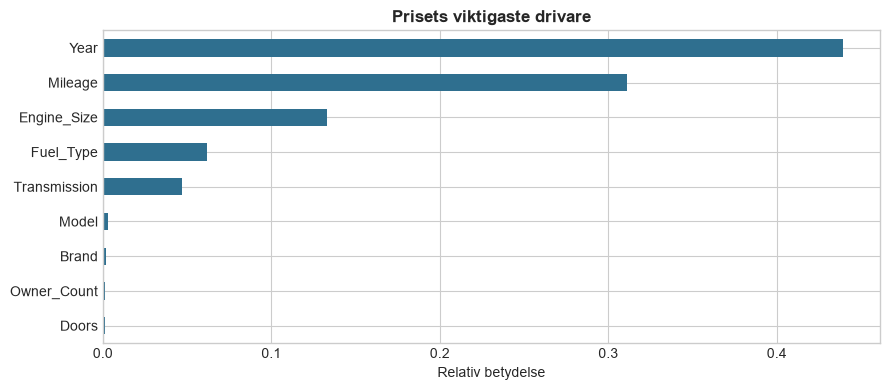

In [27]:
importance_plot = by_feature.sort_values()
importance_plot.plot(kind="barh", color="#2f6f8f", figsize=(9, 4))
plt.title("Prisets viktigaste drivare")
plt.xlabel("Relativ betydelse")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 7. Output — värdering (privat vs handlare)

Modellens prediktion = marknadsvärde (handlarnivå). Privatpris = `PRIVATE_MARGIN` under,
eftersom handlare tar påslag. Datasetet saknar säljartyp, så gapet är ett antagande.

In [28]:
def estimate(car: dict) -> dict:
    """{'privat': kr, 'handlare': kr} för en bil. `car` måste ha alla CAT+NUM-fält."""
    base = model.predict(pd.DataFrame([car])[CAT + NUM])[0]
    return {"privat": int(round(base * (1 - PRIVATE_MARGIN))),
            "handlare": int(round(base))}

example = {"Brand": "Toyota", "Model": "Corolla", "Year": 2019, "Engine_Size": 2.0,
           "Fuel_Type": "Petrol", "Transmission": "Automatic", "Mileage": 60000,
           "Doors": 4, "Owner_Count": 1}
estimate(example)

{'privat': 124341, 'handlare': 142921}

### Jämför priset med andra bilar från samma år

Här jämför vi annonspriset med det faktiska genomsnittet för samma årsmodell. Den linjära regressionen visar dessutom den övergripande prisutvecklingen mellan årsmodeller.

In [29]:
def compare_with_year_average(year: int, asking_price: int) -> dict:
    """Jämför ett pris med snittpriset för samma årsmodell."""
    year_rows = year_average[year_average["Year"] == year]
    if year_rows.empty:
        expected = float(year_model.predict([[year]])[0])
        source = "linjär trend"
    else:
        expected = float(year_rows["price_sek"].iloc[0])
        source = "årsmodellens snitt"

    difference = expected - asking_price
    difference_pct = difference / expected
    verdict = ("billigare än jämförelsepriset" if difference_pct >= DEAL_THRESHOLD
               else "dyrare än jämförelsepriset" if difference_pct <= -DEAL_THRESHOLD
               else "nära jämförelsepriset")
    return {
        "årsmodell": year,
        "annonspris": int(asking_price),
        "jämförelsepris": int(round(expected)),
        "skillnad_kr": int(round(difference)),
        "skillnad_procent": round(difference_pct * 100, 1),
        "bedömning": verdict,
        "källa": source,
    }

compare_with_year_average(2019, 150_000)

{'årsmodell': 2019,
 'annonspris': 150000,
 'jämförelsepris': 128026,
 'skillnad_kr': -21974,
 'skillnad_procent': -17.2,
 'bedömning': 'dyrare än jämförelsepriset',
 'källa': 'årsmodellens snitt'}

## 8. Output — fyndanalys

Tre vinklar för en fyndjägare: är *ett* pris ett fynd (`deal`), vad kostar liknande bilar
(`comparables`), och vilka annonser i datan är mest underprissatta (`rank_deals`).

*Obs:* `rank_deals` predikterar in-sample (raderna finns i träningsdatan), så residualerna
är optimistiskt små — duger för relativa fynd i ett skolprojekt.

In [30]:
def deal(car: dict, asking: int) -> dict:
    predicted = model.predict(pd.DataFrame([car])[CAT + NUM])[0]
    pct = (predicted - asking) / predicted
    verdict = ("fynd" if pct >= DEAL_THRESHOLD
               else "dyr" if pct <= -DEAL_THRESHOLD else "marknadspris")
    return {"predicted": int(predicted), "asking": asking,
            "pct_below_market": round(pct, 3), "verdict": verdict}

def comparables(brand: str, car_model: str) -> dict:
    same = df[(df["Brand"] == brand) & (df["Model"] == car_model)]["price_sek"]
    if same.empty:
        return {"n": 0}
    return {"n": int(same.size), "median": int(same.median()),
            "min": int(same.min()), "max": int(same.max())}

print("deal:", deal(example, 150_000))
print("comparables:", comparables("Toyota", "Corolla"))

deal: {'predicted': 142921, 'asking': 150000, 'pct_below_market': np.float64(-0.05), 'verdict': 'marknadspris'}
comparables: {'n': 325, 'median': 100890, 'min': 23000, 'max': 210462}


In [31]:
def rank_deals(top: int = 10) -> pd.DataFrame:
    out = df.copy()
    out["market_price"] = model.predict(X)
    out["pct_below_market"] = ((out["market_price"] - out["price_sek"])
                                / out["market_price"]).round(3)
    cols = ["Brand", "Model", "Year", "Mileage", "price_sek",
            "market_price", "pct_below_market"]
    return out.sort_values("pct_below_market", ascending=False)[cols].head(top)

rank_deals()

,Brand,Model,Year,Mileage,price_sek,market_price,pct_below_market
2186,Hyundai,Tucson,2001,281172,23000,-249.857563,93.052
7515,Toyota,RAV4,2001,272667,23000,-796.459788,29.878
8212,Honda,Civic,2000,290305,23000,-3227.065476,8.127
1897,Ford,Focus,2004,281063,28497,33255.599938,0.143
6184,Audi,A4,2003,260266,32131,36703.620914,0.125
1217,Toyota,Corolla,2002,277426,28186,32160.870728,0.124
3467,Chevrolet,Malibu,2001,247962,33810,38570.064497,0.123
4970,Chevrolet,Equinox,2006,276465,36455,41437.214798,0.120
3510,BMW,3 Series,2007,265336,25220,28286.649790,0.108
4125,Mercedes,E-Class,2002,258150,28026,31419.555570,0.108


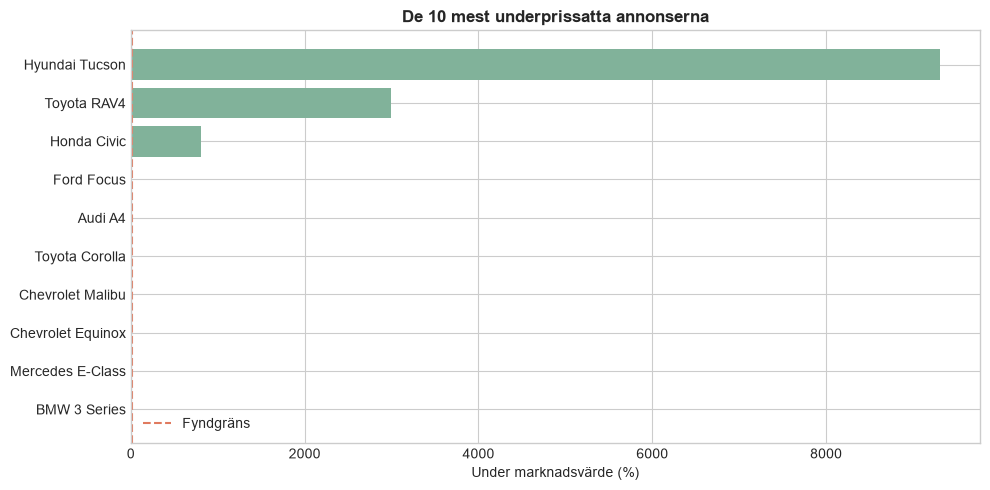

In [32]:
deals = rank_deals(10).sort_values("pct_below_market")
deal_labels = deals["Brand"] + " " + deals["Model"]
plt.figure(figsize=(10, 5))
plt.barh(deal_labels, deals["pct_below_market"] * 100, color="#81b29a")
plt.axvline(DEAL_THRESHOLD * 100, color="#e07a5f", linestyle="--", label="Fyndgräns")
plt.title("De 10 mest underprissatta annonserna")
plt.xlabel("Under marknadsvärde (%)")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.show()